# Titanic Survival Prediction — Model Building & Evaluation

In this notebook we train multiple classification models, evaluate them, and compare their performance.

**What you'll learn:**
- Train/test splitting
- Feature scaling
- Training 7 different classification models
- Cross-validation
- Hyperparameter tuning with GridSearchCV
- Model comparison and selection
- ROC curve analysis

**Models we'll test:**
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors (KNN)
5. Support Vector Machine (SVM)
6. Gradient Boosting
7. Naive Bayes

## 1. Import Libraries and Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Utility functions
from utils import evaluate_model, plot_confusion_matrix, plot_roc_curves, compare_models

sns.set_theme(style="whitegrid")
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")


In [2]:
# Load the cleaned dataset from notebook 02
df = pd.read_csv("data/titanic_cleaned.csv")
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (891, 23)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,FamilySize,IsAlone,...,Title_Mr,Title_Mrs,Title_Rare,AgeGroup_Teen,AgeGroup_Young Adult,AgeGroup_Adult,AgeGroup_Senior,FareBin_Medium,FareBin_High,FareBin_Very High
0,0,3,0,22.0,1,0,7.2500,0,2,0,...,1,0,0,0,1,0,0,0,0,0
1,1,1,1,38.0,1,0,71.2833,1,2,0,...,0,1,0,0,0,1,0,0,0,1
2,1,3,1,26.0,0,0,7.9250,0,1,1,...,0,0,0,0,1,0,0,1,0,0
3,1,1,1,35.0,1,0,53.1000,1,2,0,...,0,1,0,0,1,0,0,0,0,1
4,0,3,0,35.0,0,0,8.0500,0,1,1,...,1,0,0,0,1,0,0,1,0,0


## 2. Prepare Features and Target

In [3]:
# Separate features and target
X = df.drop(columns=["Survived"])
y = df["Survived"]

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"\nFeature columns: {X.columns.tolist()}")


Features shape: (891, 22)
Target distribution:
Survived
0    549
1    342
Name: count, dtype: int64

Feature columns: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeGroup_Teen', 'AgeGroup_Young Adult', 'AgeGroup_Adult', 'AgeGroup_Senior', 'FareBin_Medium', 'FareBin_High', 'FareBin_Very High']


In [4]:
# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining survival rate: {y_train.mean():.2%}")
print(f"Test survival rate: {y_test.mean():.2%}")


Training set: 712 samples
Test set: 179 samples

Training survival rate: 38.34%
Test survival rate: 38.55%


In [5]:
# Feature scaling — important for KNN, SVM, and Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Scaling complete. First 3 rows of scaled training data:")
X_train_scaled.head(3)


Scaling complete. First 3 rows of scaled training data:


,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,FamilySize,IsAlone,Embarked_Q,...,Title_Mr,Title_Mrs,Title_Rare,AgeGroup_Teen,AgeGroup_Young Adult,AgeGroup_Adult,AgeGroup_Senior,FareBin_Medium,FareBin_High,FareBin_Very High
692,0.829568,-0.742427,-0.322182,-0.465084,-0.466183,0.513812,-0.538382,-0.556339,0.800346,-0.289333,...,0.85332,-0.420547,-0.174329,-0.283593,0.875642,-0.592489,-0.15162,-0.583838,-0.570863,1.745123
481,-0.370945,-0.742427,0.053575,-0.465084,-0.466183,-0.662563,-0.538382,-0.556339,0.800346,-0.289333,...,0.85332,-0.420547,-0.174329,-0.283593,0.875642,-0.592489,-0.15162,-0.583838,-0.570863,-0.573025
527,-1.571457,-0.742427,0.805089,-0.465084,-0.466183,3.955399,1.857418,-0.556339,0.800346,-0.289333,...,0.85332,-0.420547,-0.174329,-0.283593,-1.142019,1.687794,-0.15162,-0.583838,-0.570863,1.745123


## 3. Train Models

We'll train 7 different models and collect their results for comparison.

In [6]:
# Store results for comparison
results = []
trained_models = {}


### 3.1 Logistic Regression

A simple linear model that predicts the probability of survival. Good baseline.


  Logistic Regression Results
  Accuracy:  0.8380
  Precision: 0.7941
  Recall:    0.7826
  F1 Score:  0.7883

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.87      0.87       110
           1       0.79      0.78      0.79        69

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



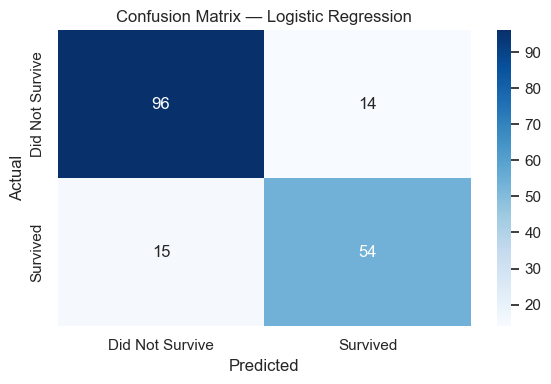

In [7]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
metrics_lr = evaluate_model(y_test, y_pred_lr, "Logistic Regression")
results.append(metrics_lr)
trained_models["Logistic Regression"] = lr

plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression")


### 3.2 Decision Tree

A tree-based model that makes decisions by splitting on feature thresholds. Easy to interpret.


  Decision Tree Results
  Accuracy:  0.7989
  Precision: 0.7797
  Recall:    0.6667
  F1 Score:  0.7188

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



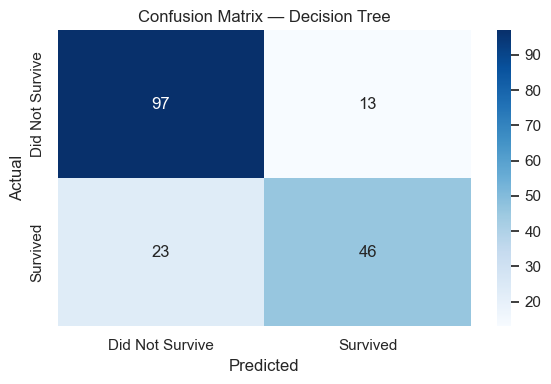

In [8]:
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
metrics_dt = evaluate_model(y_test, y_pred_dt, "Decision Tree")
results.append(metrics_dt)
trained_models["Decision Tree"] = dt

plot_confusion_matrix(y_test, y_pred_dt, "Decision Tree")


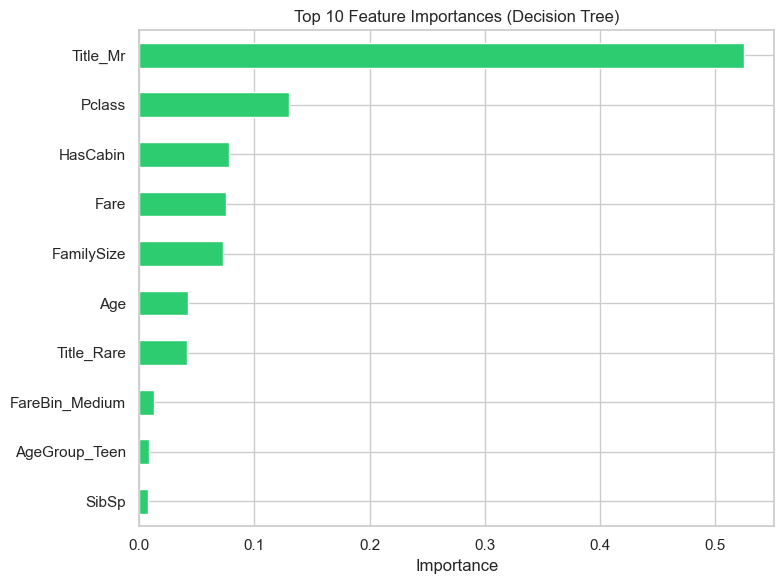

In [9]:
# Feature importance from Decision Tree
feature_imp = pd.Series(dt.feature_importances_, index=X_train.columns)
feature_imp = feature_imp.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
feature_imp.tail(10).plot(kind="barh", ax=ax, color="#2ecc71")
ax.set_title("Top 10 Feature Importances (Decision Tree)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


### 3.3 Random Forest

An ensemble of decision trees that reduces overfitting by averaging predictions from many trees.


  Random Forest Results
  Accuracy:  0.8156
  Precision: 0.7812
  Recall:    0.7246
  F1 Score:  0.7519

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



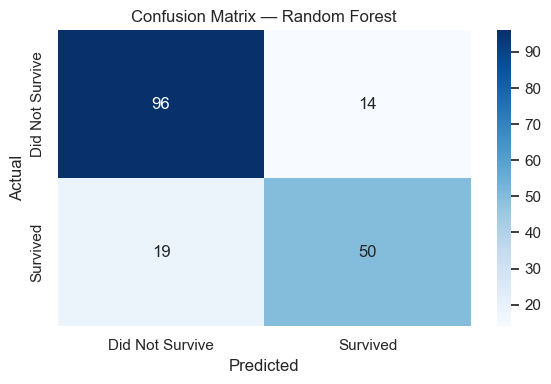

In [10]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=7)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
metrics_rf = evaluate_model(y_test, y_pred_rf, "Random Forest")
results.append(metrics_rf)
trained_models["Random Forest"] = rf

plot_confusion_matrix(y_test, y_pred_rf, "Random Forest")


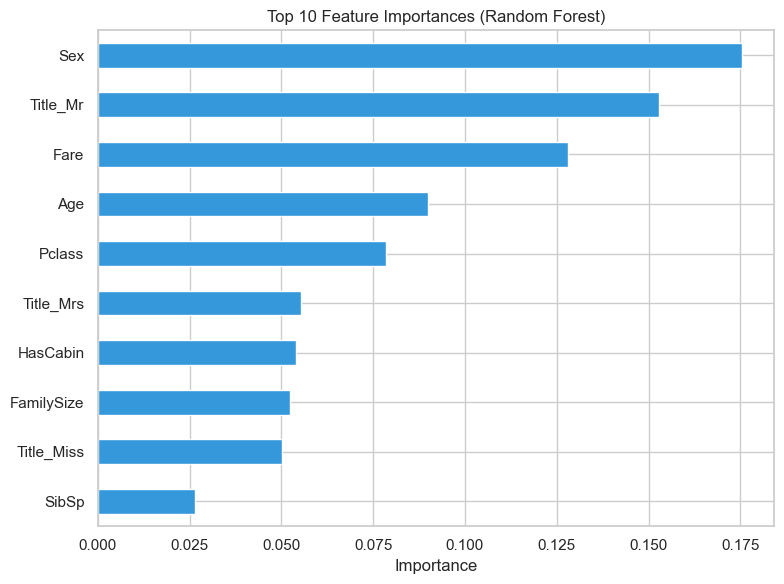

In [11]:
# Feature importance from Random Forest
feature_imp_rf = pd.Series(rf.feature_importances_, index=X_train.columns)
feature_imp_rf = feature_imp_rf.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
feature_imp_rf.tail(10).plot(kind="barh", ax=ax, color="#3498db")
ax.set_title("Top 10 Feature Importances (Random Forest)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


### 3.4 K-Nearest Neighbors (KNN)

Classifies based on the majority vote of the K closest training samples. Requires scaled features.


  K-Nearest Neighbors Results
  Accuracy:  0.7709
  Precision: 0.7500
  Recall:    0.6087
  F1 Score:  0.6720

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.87      0.82       110
           1       0.75      0.61      0.67        69

    accuracy                           0.77       179
   macro avg       0.77      0.74      0.75       179
weighted avg       0.77      0.77      0.77       179



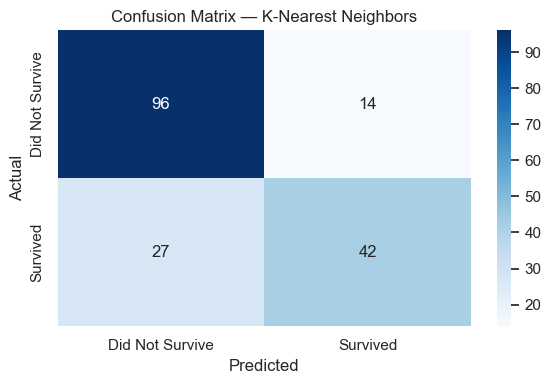

In [12]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
metrics_knn = evaluate_model(y_test, y_pred_knn, "K-Nearest Neighbors")
results.append(metrics_knn)
trained_models["K-Nearest Neighbors"] = knn

plot_confusion_matrix(y_test, y_pred_knn, "K-Nearest Neighbors")


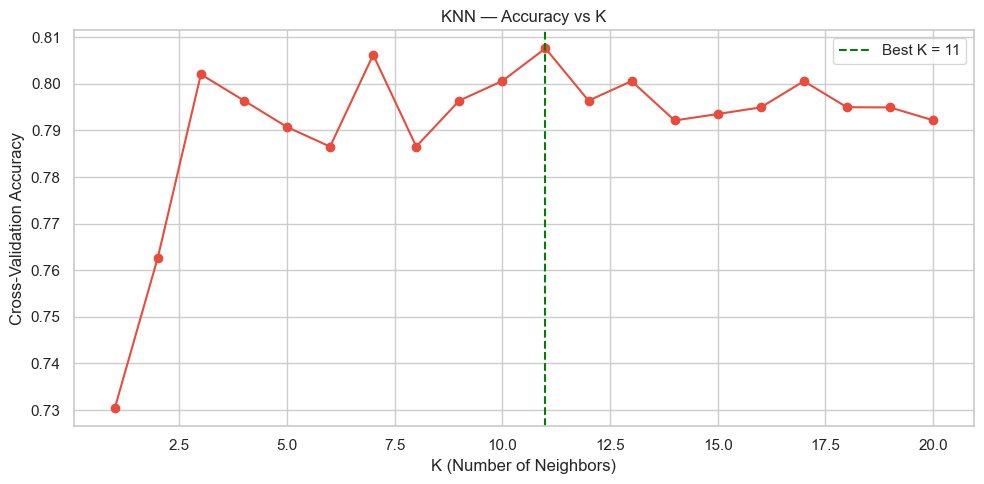

Best K: 11 with accuracy: 0.8076


In [13]:
# Find optimal K using cross-validation
k_range = range(1, 21)
k_scores = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_temp, X_train_scaled, y_train, cv=5, scoring="accuracy")
    k_scores.append(scores.mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, k_scores, marker="o", color="#e74c3c")
ax.set_title("KNN — Accuracy vs K")
ax.set_xlabel("K (Number of Neighbors)")
ax.set_ylabel("Cross-Validation Accuracy")
best_k = list(k_range)[np.argmax(k_scores)]
ax.axvline(x=best_k, color="green", linestyle="--", label=f"Best K = {best_k}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best K: {best_k} with accuracy: {max(k_scores):.4f}")


### 3.5 Support Vector Machine (SVM)

Finds the optimal hyperplane that separates classes with maximum margin.


  SVM Results
  Accuracy:  0.8268
  Precision: 0.7969
  Recall:    0.7391
  F1 Score:  0.7669

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.80      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.83       179



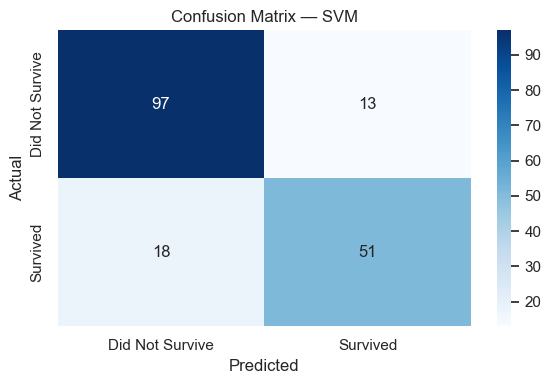

In [14]:
svm = SVC(kernel="rbf", probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
metrics_svm = evaluate_model(y_test, y_pred_svm, "SVM")
results.append(metrics_svm)
trained_models["SVM"] = svm

plot_confusion_matrix(y_test, y_pred_svm, "SVM")


### 3.6 Gradient Boosting

An ensemble method that builds trees sequentially, where each tree corrects the errors of the previous one.


  Gradient Boosting Results
  Accuracy:  0.8156
  Precision: 0.8103
  Recall:    0.6812
  F1 Score:  0.7402

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.68      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



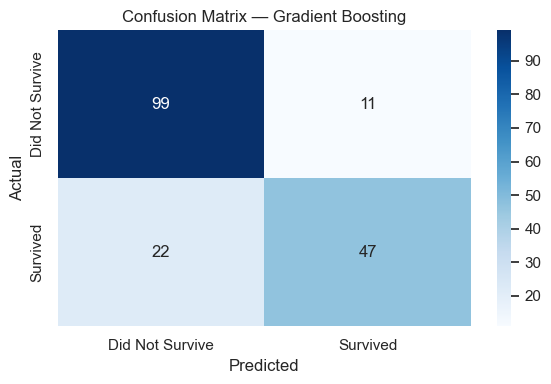

In [15]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                 max_depth=3, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
metrics_gb = evaluate_model(y_test, y_pred_gb, "Gradient Boosting")
results.append(metrics_gb)
trained_models["Gradient Boosting"] = gb

plot_confusion_matrix(y_test, y_pred_gb, "Gradient Boosting")


### 3.7 Gaussian Naive Bayes

A probabilistic classifier based on Bayes' theorem. Fast and works well with small datasets.


  Naive Bayes Results
  Accuracy:  0.7765
  Precision: 0.6883
  Recall:    0.7681
  F1 Score:  0.7260

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.78      0.81       110
           1       0.69      0.77      0.73        69

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



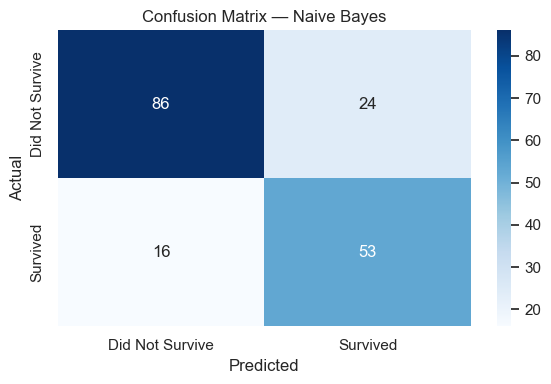

In [16]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

y_pred_nb = nb.predict(X_test_scaled)
metrics_nb = evaluate_model(y_test, y_pred_nb, "Naive Bayes")
results.append(metrics_nb)
trained_models["Naive Bayes"] = nb

plot_confusion_matrix(y_test, y_pred_nb, "Naive Bayes")


## 4. Model Comparison

In [17]:
# Compare all models
comparison_df = compare_models(results)
comparison_df.style.background_gradient(cmap="Greens", subset=["Accuracy", "Precision", "Recall", "F1 Score"])


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.837989,0.794118,0.782609,0.788321
1,SVM,0.826816,0.796875,0.739130,0.766917
2,Random Forest,0.815642,0.781250,0.724638,0.751880
3,Gradient Boosting,0.815642,0.810345,0.681159,0.740157
4,Naive Bayes,0.776536,0.688312,0.768116,0.726027
5,Decision Tree,0.798883,0.779661,0.666667,0.718750
6,K-Nearest Neighbors,0.770950,0.750000,0.608696,0.672000


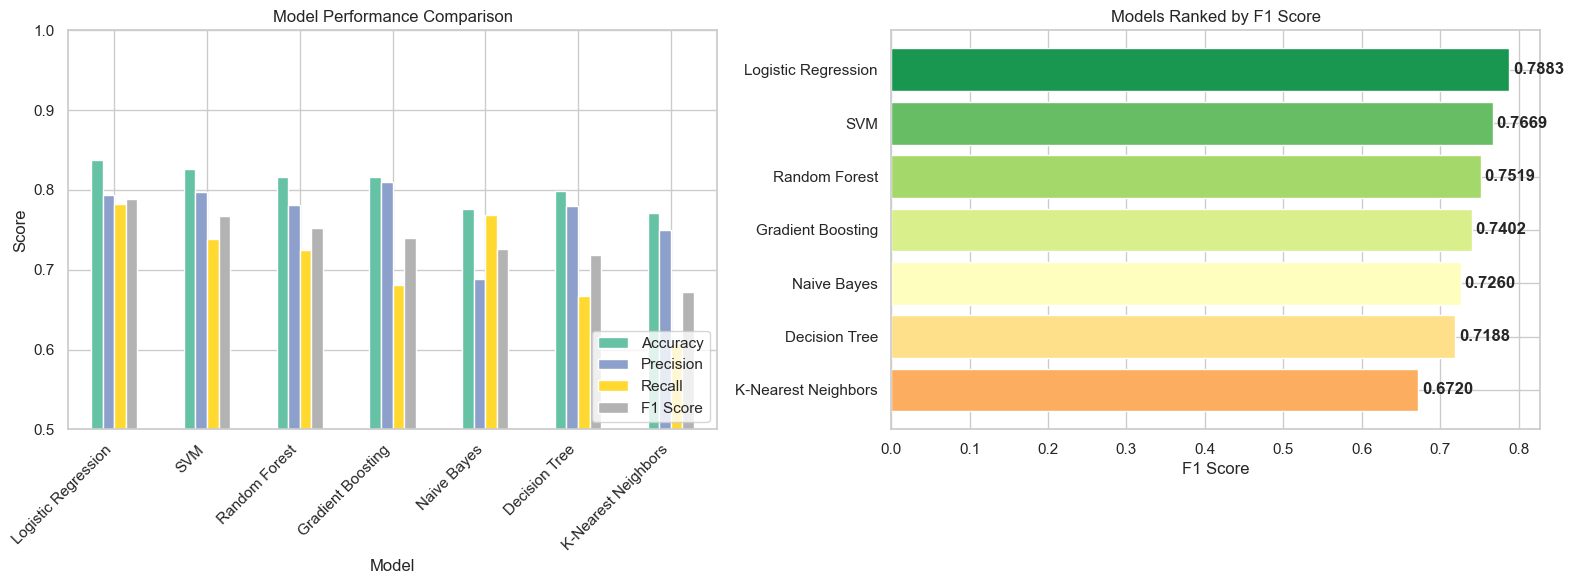

In [18]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of all metrics
comparison_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar", ax=axes[0], colormap="Set2"
)
axes[0].set_title("Model Performance Comparison")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0.5, 1.0)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")
axes[0].legend(loc="lower right")

# F1 Score ranking
sorted_df = comparison_df.sort_values("F1 Score", ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(sorted_df)))
axes[1].barh(sorted_df["Model"], sorted_df["F1 Score"], color=colors)
axes[1].set_title("Models Ranked by F1 Score")
axes[1].set_xlabel("F1 Score")
for i, v in enumerate(sorted_df["F1 Score"]):
    axes[1].text(v + 0.005, i, f"{v:.4f}", va="center", fontweight="bold")

plt.tight_layout()
plt.show()


## 5. Cross-Validation

In [19]:
# Cross-validation for all models (5-fold)
cv_results = {}

models_for_cv = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, max_depth=7),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel="rbf", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=3),
    "Naive Bayes": GaussianNB(),
}

print("5-Fold Cross-Validation Results:")
print("=" * 55)
for name, model in models_for_cv.items():
    # Use scaled data for models that need it
    if name in ["Logistic Regression", "KNN", "SVM", "Naive Bayes"]:
        scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="accuracy")
    else:
        scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    cv_results[name] = scores
    print(f"{name:25s} — Mean: {scores.mean():.4f} (+/- {scores.std():.4f})")


5-Fold Cross-Validation Results:
Logistic Regression       — Mean: 0.8175 (+/- 0.0238)
Decision Tree             — Mean: 0.7978 (+/- 0.0325)
Random Forest             — Mean: 0.8077 (+/- 0.0231)
KNN                       — Mean: 0.7907 (+/- 0.0051)
SVM                       — Mean: 0.8104 (+/- 0.0126)
Gradient Boosting         — Mean: 0.8133 (+/- 0.0342)
Naive Bayes               — Mean: 0.7782 (+/- 0.0309)


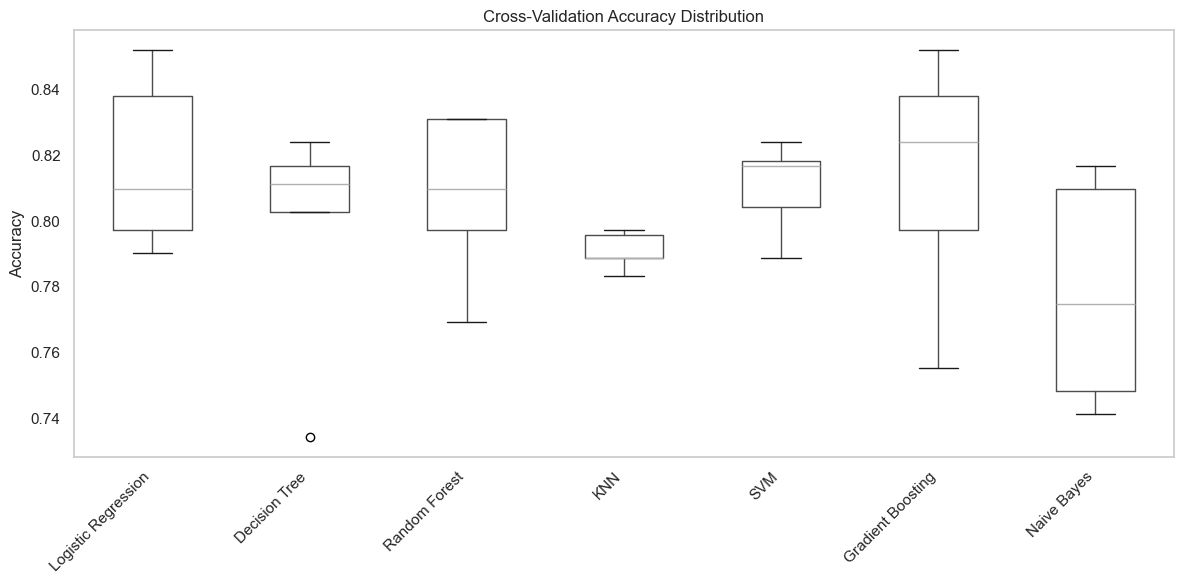

In [20]:
# Box plot of cross-validation scores
fig, ax = plt.subplots(figsize=(12, 6))
cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(ax=ax, grid=False)
ax.set_title("Cross-Validation Accuracy Distribution")
ax.set_ylabel("Accuracy")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 6. ROC Curve Comparison

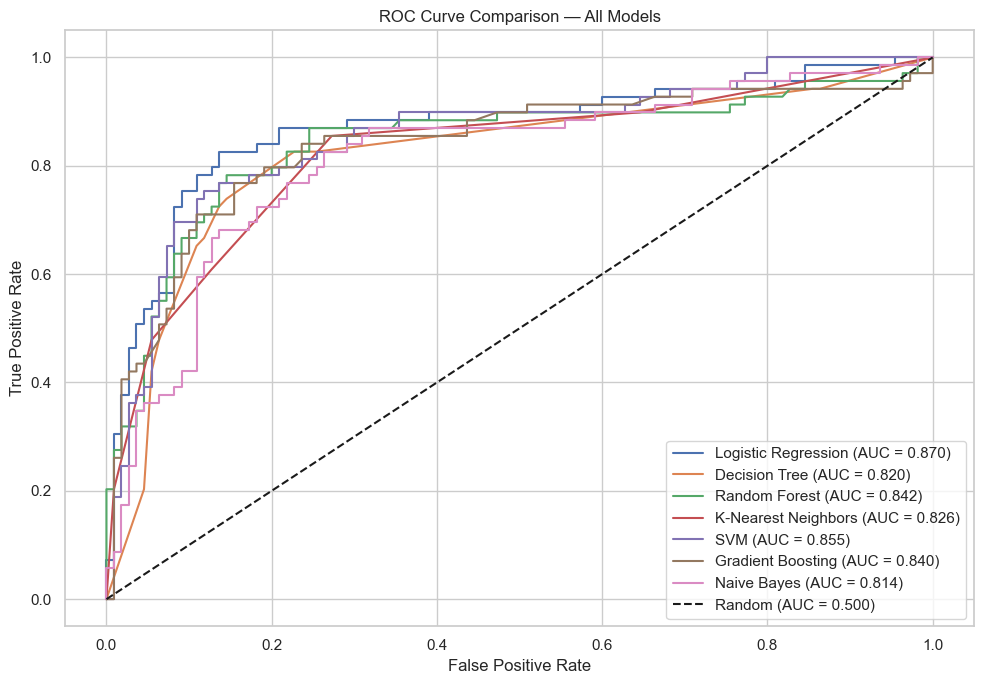

In [21]:
# Plot ROC curves for all models
# Note: KNN, SVM, LR, NB use scaled data; DT, RF, GB use unscaled
plt.figure(figsize=(10, 7))

for name, model in trained_models.items():
    # Choose the right test data
    if name in ["Logistic Regression", "K-Nearest Neighbors", "SVM", "Naive Bayes"]:
        X_eval = X_test_scaled
    else:
        X_eval = X_test
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_eval)[:, 1]
    else:
        y_prob = model.decision_function(X_eval)
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — All Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 7. Hyperparameter Tuning — Random Forest

Let's tune the best-performing model (Random Forest) using GridSearchCV to squeeze out more performance.

In [22]:
# Define hyperparameter grid
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV F1 score: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 108 candidates, totalling 540 fits


/Users/taimour/conda/envs/personal/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/taimour/conda/envs/personal/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/taimour/conda/envs/personal/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from usi


Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best CV F1 score: 0.7616



  Tuned Random Forest Results
  Accuracy:  0.8045
  Precision: 0.7656
  Recall:    0.7101
  F1 Score:  0.7368

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       110
           1       0.77      0.71      0.74        69

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



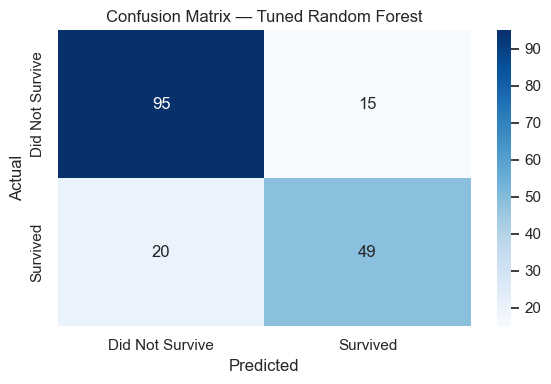

In [23]:
# Evaluate tuned model
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

metrics_tuned = evaluate_model(y_test, y_pred_tuned, "Tuned Random Forest")
plot_confusion_matrix(y_test, y_pred_tuned, "Tuned Random Forest")


## 8. Feature Importance — Final Model

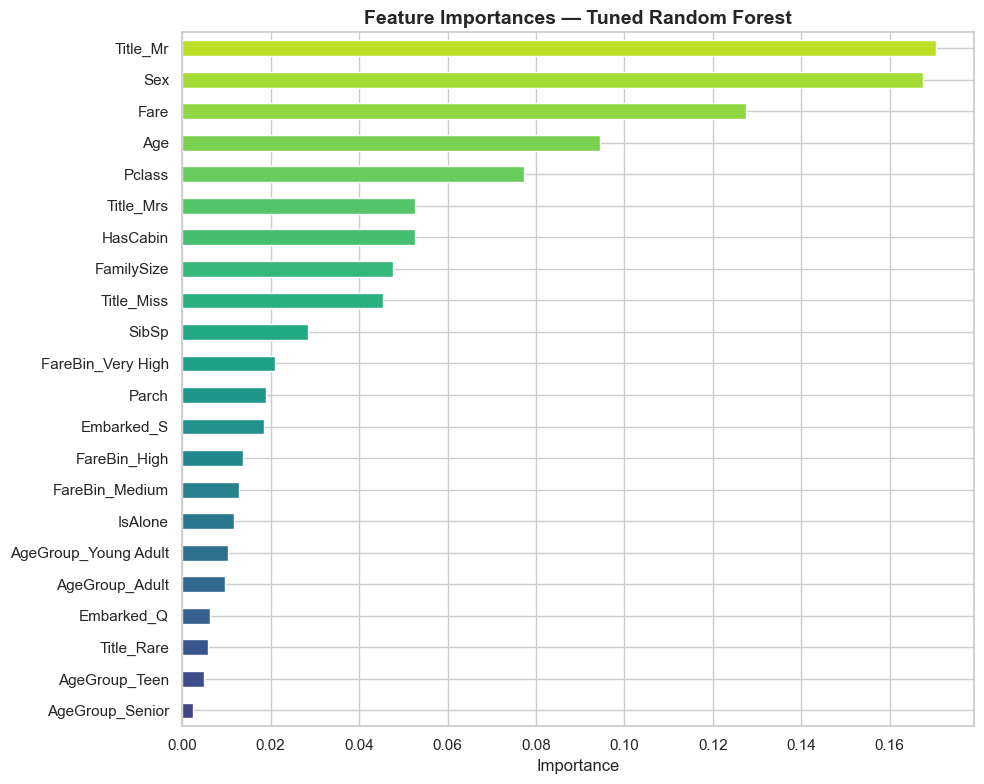


Top 5 most important features:
Pclass      0.077209
Age         0.094480
Fare        0.127540
Sex         0.167501
Title_Mr    0.170512
dtype: float64


In [24]:
# Feature importance from the tuned model
feature_imp_final = pd.Series(best_rf.feature_importances_, index=X_train.columns)
feature_imp_final = feature_imp_final.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(feature_imp_final)))
feature_imp_final.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Feature Importances — Tuned Random Forest", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(feature_imp_final.tail(5))


## 9. Make Predictions on New Data

Let's see how to use the trained model to predict survival for a new passenger.

In [25]:
# Example: Predict survival for a new passenger
# Create a sample with the same features as our training data
sample_passenger = pd.DataFrame([{
    col: 0 for col in X_train.columns
}])

# 25-year-old female in 1st class, traveling alone, fare $100, embarked at Cherbourg
sample_passenger["Pclass"] = 1
sample_passenger["Sex"] = 1  # female
sample_passenger["Age"] = 25
sample_passenger["Fare"] = 100
sample_passenger["FamilySize"] = 1
sample_passenger["IsAlone"] = 1
sample_passenger["HasCabin"] = 1

prediction = best_rf.predict(sample_passenger)[0]
probability = best_rf.predict_proba(sample_passenger)[0]

print("Sample Passenger: 25-year-old female, 1st class, solo traveler")
print(f"Prediction: {'Survived' if prediction == 1 else 'Did Not Survive'}")
print(f"Probability — Did Not Survive: {probability[0]:.2%}")
print(f"Probability — Survived: {probability[1]:.2%}")


Sample Passenger: 25-year-old female, 1st class, solo traveler
Prediction: Survived
Probability — Did Not Survive: 13.18%
Probability — Survived: 86.82%


## 10. Final Summary

### Model Performance Summary

In [26]:
# Final comparison including tuned model
all_results = results + [metrics_tuned]
final_df = compare_models(all_results)
final_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.837989,0.794118,0.782609,0.788321
1,SVM,0.826816,0.796875,0.739130,0.766917
2,Random Forest,0.815642,0.781250,0.724638,0.751880
3,Gradient Boosting,0.815642,0.810345,0.681159,0.740157
4,Tuned Random Forest,0.804469,0.765625,0.710145,0.736842
5,Naive Bayes,0.776536,0.688312,0.768116,0.726027
6,Decision Tree,0.798883,0.779661,0.666667,0.718750
7,K-Nearest Neighbors,0.770950,0.750000,0.608696,0.672000


### Key Takeaways

1. **Sex, Fare, and Pclass** were the most important features for predicting survival
2. **Ensemble methods** (Random Forest, Gradient Boosting) generally outperformed simpler models
3. **Feature engineering** (Title, FamilySize, HasCabin) provided meaningful signal
4. **Hyperparameter tuning** with GridSearchCV improved the Random Forest model
5. **Cross-validation** helped us assess model stability and avoid overfitting

### What to Try Next
- Try XGBoost or LightGBM for potentially better performance
- Experiment with different feature combinations
- Try ensemble stacking (combining multiple models)
- Submit predictions to the Kaggle Titanic competition